In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [4]:
fp_folder = '/Users/tplas/Downloads/doi_10_5061_dryad_m905qfv5p__v20230227/'
contents = os.listdir(fp_folder)
contents

['1994-2021_Field_nr-traps_deposit.csv',
 '1994-2021_Field_timing_deposit.csv',
 'CatFood2021_deposit.csv',
 'README.md',
 '1994-2021_Field_Eggs_deposit.csv',
 '1994-2021_Field_PopNum_raw_deposit.csv']

In [12]:
tmp = pd.read_csv(os.path.join(fp_folder, contents[5]))
tmp

,YearCatch,AreaShortName,AreaName,NovemberDate,Site,Tree,NoFemale,NoMale
0,1994,HV,Hoge Veluwe,-9,98,5,0.0,0.0
1,1994,HV,Hoge Veluwe,-9,98,7,0.0,0.0
2,1994,HV,Hoge Veluwe,-9,98,13,0.0,0.0
3,1994,HV,Hoge Veluwe,-9,98,14,0.0,0.0
4,1994,HV,Hoge Veluwe,-9,98,15,0.0,0.0
...,...,...,...,...,...,...,...,...
12918,2021,WA,Warnsborn,50,3,6,0.0,0.0
12919,2021,WA,Warnsborn,50,3,7,0.0,0.0
12920,2021,WA,Warnsborn,50,3,8,0.0,0.0
12921,2021,WA,Warnsborn,50,3,10,0.0,0.0


<Axes: xlabel='NovemberDate', ylabel='NoFemale'>

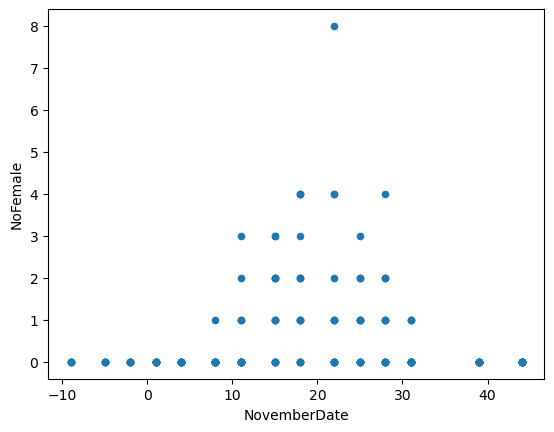

In [17]:
tmp[np.logical_and(tmp['YearCatch'] == 1994, tmp['AreaShortName'] == 'HV')].plot(x='NovemberDate', y='NoFemale', kind='scatter')